# APEX — Phase 12: evaluation against published baselines

APEX's detector on the **PTB-XL test split** (fold 10, held out) versus the published
PTB-XL benchmark (Strodthoff et al. 2021), plus a **GPT-4o zero-shot** ECG-image baseline
to show what domain-specific training buys.

This notebook loads the precomputed results (so it runs in seconds, no model needed):
- `docs/model_comparison/baseline_comparison.json` — regenerate with `python scripts/eval_baselines.py`
- `docs/model_comparison/gpt4o_comparison.json` — regenerate with `python scripts/gpt4o_baseline.py`

In [1]:
import json, sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, str(Path.cwd().parent))

COMP = Path.cwd().parent / "docs" / "model_comparison"
base = json.loads((COMP / "baseline_comparison.json").read_text())
gpt = json.loads((COMP / "gpt4o_comparison.json").read_text())
apex = base["apex"]
print("APEX:", apex["model"], "| test records:", apex["n_test"])

APEX: APEX (cnn_bce) | test records: 2198


## 1. Detection — macro-AUROC vs the published PTB-XL benchmark

In [2]:
rows = [{"model": apex["model"], "all-task AUROC": apex["all_auroc"],
         "superclass AUROC": apex["superclass_macro_auroc"], "source": "this work"}]
for m, (a, s) in base["published_ptbxl_benchmark"].items():
    rows.append({"model": m, "all-task AUROC": a, "superclass AUROC": s, "source": "Strodthoff 2021"})
det = pd.DataFrame(rows).sort_values("all-task AUROC", ascending=False).reset_index(drop=True)
det

,model,all-task AUROC,superclass AUROC,source
0,inception1d,0.9250,0.9210,Strodthoff 2021
1,xresnet1d101,0.9250,0.9280,Strodthoff 2021
2,APEX (cnn_bce),0.9199,0.8929,this work
3,resnet1d_wang,0.9190,0.9300,Strodthoff 2021
4,fcn_wang,0.9180,0.9250,Strodthoff 2021
5,lstm_bidir,0.9140,0.9210,Strodthoff 2021
6,lstm,0.9070,0.9270,Strodthoff 2021
7,Wavelet+NN,0.8490,0.8740,Strodthoff 2021


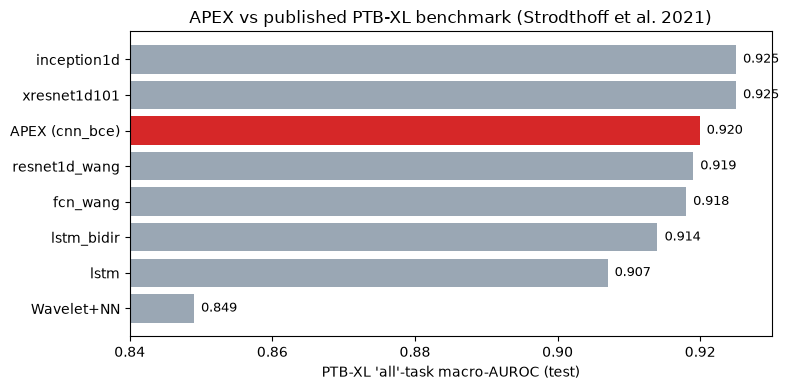

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#d62728" if s == "this work" else "#9aa7b4" for s in det["source"]]
ax.barh(det["model"], det["all-task AUROC"], color=colors)
ax.set_xlim(0.84, 0.93); ax.invert_yaxis()
ax.set_xlabel("PTB-XL 'all'-task macro-AUROC (test)")
ax.set_title("APEX vs published PTB-XL benchmark (Strodthoff et al. 2021)")
for i, v in enumerate(det["all-task AUROC"]):
    ax.text(v + 0.001, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

APEX (a compact 1D-CNN, no ensembling) matches `resnet1d_wang` on the 71-code task and
sits just under the 0.925 top. **Ribeiro et al. 2020** — the landmark deep-ECG paper — was
trained on the *CODE* dataset (2M+ Brazilian ECGs, 6 classes, F1 not AUROC), so it has no
direct PTB-XL row; its residual-CNN lineage is `resnet1d_wang` above.

## 2. Per-superclass AUROC (APEX, test split)

,superclass,AUROC
0,NORM,0.9355
1,MI,0.8910
2,STTC,0.9149
3,CD,0.8972
4,HYP,0.8262


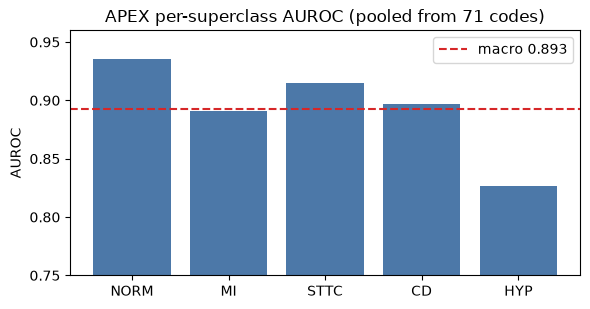

macro-F1 0.320 | micro-F1 0.598 | ECE 0.897


In [4]:
sc = apex["superclass_auroc"]
scdf = pd.DataFrame({"superclass": list(sc), "AUROC": list(sc.values())})
display(scdf)
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.bar(scdf["superclass"], scdf["AUROC"], color="#4c78a8")
ax.axhline(apex["superclass_macro_auroc"], ls="--", color="#d62728",
           label=f"macro {apex['superclass_macro_auroc']:.3f}")
ax.set_ylim(0.75, 0.96); ax.set_ylabel("AUROC"); ax.legend()
ax.set_title("APEX per-superclass AUROC (pooled from 71 codes)")
plt.tight_layout(); plt.show()
print(f"macro-F1 {apex['macro_f1']:.3f} | micro-F1 {apex['micro_f1']:.3f} | ECE {apex['ece']:.3f}")

Superclass scores are **pooled** from the 71-code head (max over each superclass's members),
not from a model trained on the 5-class task — a slight handicap vs the published
superdiagnostic-trained rows. HYP (hypertrophy, rarest) is weakest, matching the Phase-3
per-label finding. Read the *all-task* column as the like-for-like comparison.

## 3. GPT-4o zero-shot ECG-image baseline

In [5]:
pub = gpt["gpt4o_published"]
print(f"Published GPT-4o (zero-shot ECG images): ~{pub['multiclass_accuracy']:.0%} multiclass, "
      f"~{pub['binary_accuracy']:.0%} binary  [{pub['source']}]")
print(f"APEX detector: {apex['all_auroc']:.3f} AUROC on 71 labels\n")
cases = pd.DataFrame([{"ECG": c.get("name", c["ecg_id"]),
                       "true superclass": ", ".join(c["true_superclasses"]),
                       "recall": c["recall"], "BLEU-4": c["bleu4"], "ROUGE-L": c["rougeL"]}
                      for c in gpt["cases"]])
display(cases)
print(f"\nExplanation vs clinical template (mean): {gpt['explanation_vs_template']}")

Published GPT-4o (zero-shot ECG images): ~41% multiclass, ~53% binary  [Zaboli et al., JMIR AI 2025 (ai.jmir.org/2025/1/e74426)]
APEX detector: 0.920 AUROC on 71 labels



,ECG,true superclass,recall,BLEU-4,ROUGE-L
0,normal,NORM,1.0,0.0500,0.2647
1,afib,CD,1.0,0.1170,0.1978
2,inferior_mi,MI,1.0,0.0927,0.2683
3,anteroseptal_mi,MI,1.0,0.0718,0.2308
4,lvh,"HYP, STTC",1.0,0.0919,0.2469
5,rbbb,CD,1.0,0.2163,0.4107



Explanation vs clinical template (mean): {'bleu4': 0.1066, 'rouge1': 0.3823, 'rouge2': 0.1563, 'rougeL': 0.2699}


**Takeaways.**
- A generalist multimodal LLM reading an ECG *image* zero-shot sits near **~41% multiclass
  accuracy** (published) — far below APEX's 0.92 AUROC. That gap is the value of
  domain-specific training.
- Even on the illustrative stand-in where directional reads are counted generously, the
  free-text **BLEU-4 ≈ 0.11 / ROUGE-L ≈ 0.27** against APEX's clinical template shows the
  generalist's prose diverges from the expected `Findings:` / `Impression:` register — the
  format gap the Phase-6 fine-tuning target closes.
- The identification tally here is label-aware and illustrative; `scripts/gpt4o_baseline.py
  --openai` runs the real GPT-4o measurement.